In [1]:
import time
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
import random
load_dotenv = dotenv.load_dotenv('../.env')

# load local library
from timex import clustering
from timex import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

import datetime
from time import sleep

from aeon import datasets

/home/bramiozo/.cache/pypoetry/virtualenvs/timex-dV5LCb6l-py3.12/lib/python3.12/site-packages/nolds/datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
#dataset = datasets.load_regression("FloodModeling1")
#dataset = datasets.load_japanese_vowels()
dataset = datasets.load_osuleaf()

In [3]:
dataset[0].shape

(442, 1, 427)

In [4]:
ts_data = pd.DataFrame(dataset[0].squeeze())
ts_label = dataset[1]

In [5]:
ts_label_df = pd.DataFrame()
ts_label_df['label'] = ts_label
ts_label_df['sample'] = range(442)

In [6]:
ts_data['sample'] = ts_data.index 
ts_data_unp = ts_data.melt(id_vars='sample', value_vars=list(range(ts_data.shape[1]-1)))\
                     .sort_values(by=['sample', 'variable'])
ts_data_unp = ts_data_unp.rename(columns = {'variable': 'Time'})

In [7]:
ts_data_unp

,sample,Time,value
0,0,0,0.550671
442,0,1,0.464716
884,0,2,0.375261
1326,0,3,0.293060
1768,0,4,0.206427
...,...,...,...
186965,441,422,1.761683
187407,441,423,1.838726
187849,441,424,1.927078
188291,441,425,2.004444


In [8]:
# create heterogeinity
MAX_CUT_PERC = 0.1
MAX_MASK_PERC = 0.25
MAX_TIME_OVERALL = 426

ts_data_unp_heter = pd.DataFrame()
for s in ts_data_unp['sample'].unique():
    temp_ts = ts_data_unp.loc[(ts_data_unp['sample']==s) & (ts_data_unp['Time']<MAX_TIME_OVERALL), ['sample', 'Time', 'value']]

    max_t = temp_ts['Time'].max()
    # randomly subtract from max_t 
    new_max_t = max_t - MAX_CUT_PERC*np.random.random()*max_t
    temp_ts = temp_ts.query(f'Time<{new_max_t}')

    # random mask from remainder
    val_rem = temp_ts['value'].values
    mask = np.random.rand(val_rem.shape[0]) < MAX_MASK_PERC
    val_rem[mask] = np.nan

    temp_ts = temp_ts.assign(value=val_rem)

    ts_data_unp_heter = pd.concat([ts_data_unp_heter, temp_ts], axis=0)

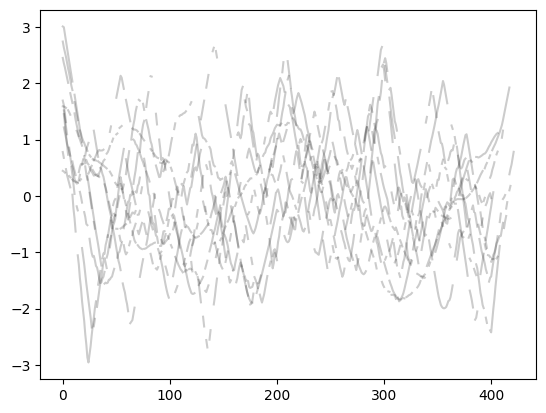

In [9]:
# plot 10 random samples
for s in ts_data_unp_heter.sample(n=10)['sample']:
    tsv = ts_data_unp_heter.query(f'sample=={s}')['value']
    tst = ts_data_unp_heter.query(f'sample=={s}')['Time']

    plt.plot(tst, tsv, color='black', alpha=0.2);

In [65]:
MIN_TIME = 1 
MAX_TIME = 450
MIN_MEAS_COUNT = 5 # measurements
NUM_CLUSTERS = 6
INTERP_RES = 1
ANALYSIS_RES = 1
SMOOTHING_WINDOW = 7
CLUSTERING_ALGO='gmm'
CLUSTER_KWARGS={"reg_covar": 1e-1, "covariance_type": "diag"}
SMOOTHING_TYPE = 'gaussian_kernel'  # 'gaussian_kernel' or 'rolling_mean', 'gaussian_kernel_simple, 'box_kernel'
META_KEYS = ['sample', 'Time']
ID_KEY = 'sample'
TIME_KEY = 'Time'
RAW_VAL_COL = 'value'

In [66]:
ts_data_unp_heter = ts_data_unp_heter.reset_index(drop=True)
ts_data_unp_heter = ts_data_unp_heter.dropna(subset='value')

In [67]:
ts_clusterer = clustering.CrossSectionalClustering(smoothing=True, 
                                                   smoothing_type=SMOOTHING_TYPE,
                                                   smoothing_window_size=SMOOTHING_WINDOW,
                                                   n_skip=2,
                                                   interpolation=True, 
                                                   interpolation_resolution=INTERP_RES,
                                                   interpolation_keep_init=True,
                                                   analysis_resolution=ANALYSIS_RES,
                                                   min_measurements_per_id=MIN_MEAS_COUNT, 
                                                   min_time=MIN_TIME,
                                                   max_time=MAX_TIME,
                                                   clustering_algorithm=CLUSTERING_ALGO,
                                                   n_clusters=NUM_CLUSTERS, 
                                                   cluster_kwargs=CLUSTER_KWARGS,
                                                   id_column=ID_KEY, 
                                                   time_column=TIME_KEY,
                                                   feature_columns=[RAW_VAL_COL],
                                                   imputation_method='knn',
                                                   cross_standardisation=True,
                                                   normalise_timeseries= "group",
                                                   normalisation_method="standard",
                                                   add_ts_meta=True,
                                                   verbose=True)

2025-11-20 21:50:00,489 - timex.clustering - DEBUG - CrossSectionalClustering initialized


In [68]:
nunique_samples = ts_data_unp_heter['sample'].nunique()
rand_selection = np.random.choice(ts_data_unp_heter['sample'].unique(), size=nunique_samples)
ts_clusterer.fit(ts_data_unp_heter.loc[ts_data_unp_heter['sample'].isin(rand_selection)])

2025-11-20 21:50:01,469 - timex.clustering - INFO - Starting CrossSectionalClustering.fit(); TS shape (83979, 3)


value


2025-11-20 21:50:01,471 - timex.clustering - INFO - Processing feature column: value


2025-11-20 21:50:01,508 - timex.clustering - INFO - Filtering completed for value in 0.0333 seconds. TS: (83979, 3)
2025-11-20 21:50:01,680 - timex.clustering - INFO - Meta data extraction completed for value in 0.1716 seconds
100%|██████████| 276/276 [00:00<00:00, 764.84it/s]
2025-11-20 21:50:02,181 - timex.clustering - INFO - Interpolation completed for value in 0.4998 seconds, TS: (124200, 3)
100%|██████████| 276/276 [00:00<00:00, 613.88it/s]
2025-11-20 21:50:02,770 - timex.clustering - INFO - Smoothing completed for value in 0.5872 seconds, TS: (124200, 3)
2025-11-20 21:50:02,775 - timex.clustering - INFO - Selection after pruning NaNs for value in 0.5872 seconds, TS: (111619, 3)
100%|██████████| 276/276 [00:04<00:00, 67.21it/s]
2025-11-20 21:50:07,015 - timex.clustering - INFO - Normalization completed for value in 4.2394 seconds, TS: (111619, 3)


Processing custom features..


  0%|          | 1/276 [00:00<00:32,  8.44it/s]/home/bramiozo/.cache/pypoetry/virtualenvs/timex-dV5LCb6l-py3.12/lib/python3.12/site-packages/scipy/stats/_entropy.py:146: RuntimeWarning: divide by zero encountered in divide
  pk = 1.0*pk / xp.sum(pk, axis=axis, keepdims=True)  # type: ignore[operator]
/home/bramiozo/DEV/TimEx/src/timex/extractor.py:1699: RuntimeWarning: divide by zero encountered in scalar divide
  return max_v / mean_v
 80%|████████  | 222/276 [00:28<00:06,  7.92it/s]/home/bramiozo/DEV/TimEx/src/timex/extractor.py:1027: RuntimeWarning: divide by zero encountered in log2
  entropy = np.nansum(psd_norm * np.log2(psd_norm))
/home/bramiozo/DEV/TimEx/src/timex/extractor.py:1027: RuntimeWarning: invalid value encountered in multiply
  entropy = np.nansum(psd_norm * np.log2(psd_norm))
100%|██████████| 276/276 [00:35<00:00,  7.82it/s]
2025-11-20 21:50:42,371 - timex.clustering - INFO - Cross-sectional extraction completed for value in 35.3547 seconds, TS cross: (276, 206)
2025

CrossSectionalClustering(add_ts_meta=True, analysis_resolution=1,
                         cluster_kwargs={'covariance_type': 'diag',
                                         'reg_covar': 0.1},
                         clustering_algorithm=GaussianMixture(covariance_type='diag',
                                                              n_components=6,
                                                              random_state=42,
                                                              reg_covar=0.1),
                         extractors={'antropy_features': False,
                                     'catch22_features': False,
                                     'cesium_features': False,
                                     'custom_features': True,
                                     'katz_features': False,
                                     'nolds_features': False,
                                     'tsfel_features': False,
                                     'tsfresh_features': False},
                         feature_columns=['value'], id_column='sample',
                         imputation_kwargs={}, interpolation=True,
                         interpolation_keep_init=True, max_time=450,
                         min_measurements_per_id=5, min_time=1, n_clusters=6,
                         n_skip=2, smoothing=True, smoothing_window_size=7,
                         time_column='Time', verbose=True)

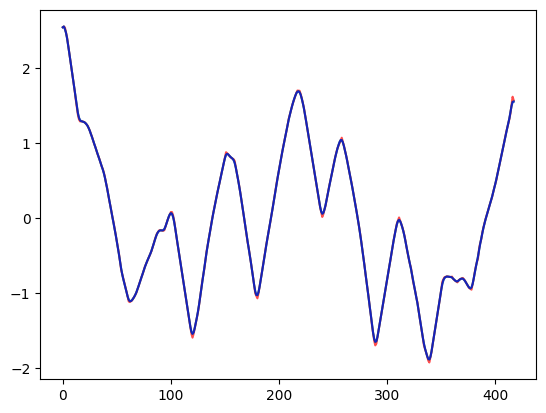

In [69]:
# plot 10 random samples
for s in ts_clusterer.ts_filtered.sample(n=1)['sample']:
    tsv = ts_clusterer.ts_filtered.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_filtered.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='red', alpha=0.7)

    tsv = ts_clusterer.ts_smoothed.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_smoothed.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='green', alpha=0.7)

    tsv = ts_clusterer.ts_smoothed_filtered.query(f'sample=={s}')['value']
    tst = ts_clusterer.ts_smoothed_filtered.query(f'sample=={s}')['Time']
    plt.plot(tst, tsv, color='blue', alpha=0.7)

In [70]:
res_cluster = pd.DataFrame(zip(ts_clusterer.ts_cross_combined.index, ts_clusterer.predict()), columns=['ID', 'cluster'])
res_cluster['cluster'] = res_cluster['cluster'].astype(int)
res_final = ts_data_unp_heter.merge(res_cluster, how='left', left_on='sample', right_on='ID').dropna(subset='ID')
res_final = res_final.merge(ts_label_df, how='left', left_on='sample', right_on='sample')

<Axes: xlabel='Time', ylabel='value'>

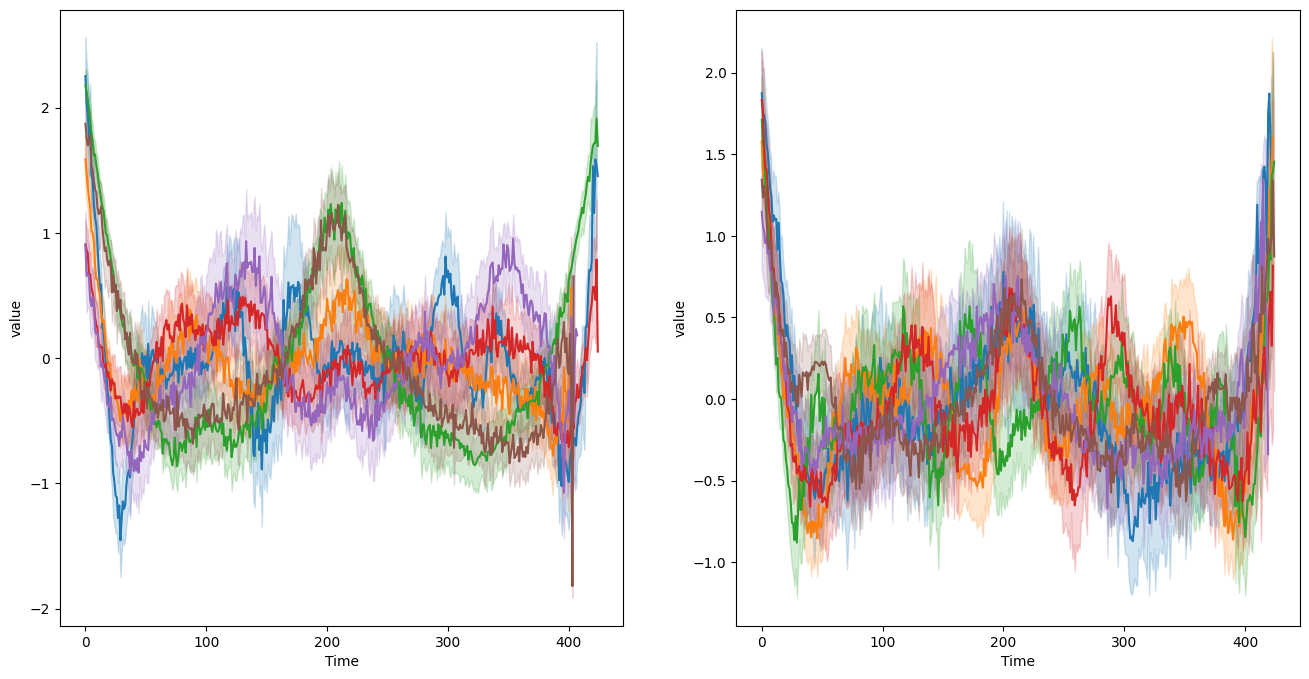

In [71]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='cluster',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[0],
             legend=False,)
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='label',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[1],
             legend=False,)

In [72]:
ts_clusterer.predict_proba()

array([[1.07703425e-078, 6.15900643e-041, 9.02954067e-077,
        3.93845812e-048, 1.00000000e+000, 2.08831592e-071],
       [6.47242852e-016, 8.89239377e-063, 2.42338620e-036,
        1.00000000e+000, 6.45804216e-051, 4.80693130e-068],
       [9.99999981e-001, 3.28469196e-076, 5.85548578e-052,
        1.92624238e-008, 1.50455132e-070, 1.05778522e-111],
       ...,
       [1.51493337e-039, 2.14357968e-070, 2.73346518e-010,
        1.00000000e+000, 1.45641207e-036, 9.21729388e-050],
       [4.25877998e-045, 2.00233241e-015, 3.72479779e-010,
        1.92771748e-026, 1.81886498e-019, 1.00000000e+000],
       [3.29318949e-066, 3.43068524e-020, 6.30586254e-072,
        1.21530534e-091, 1.04342580e-035, 1.00000000e+000]])

In [73]:
ts_clusterer.get_scores()

{'davies_bouldin': np.float64(2.8393449212286472),
 'calinski_harabasz': np.float64(17.11359731699072),
 'silhouette': np.float64(0.05648356154609342),
 'aic': np.float64(104756.76118053817),
 'bic': np.float64(111378.47436393485),
 'mep': np.float64(0.00641530408534986),
 'mpp': np.float64(0.9977834407917217)}

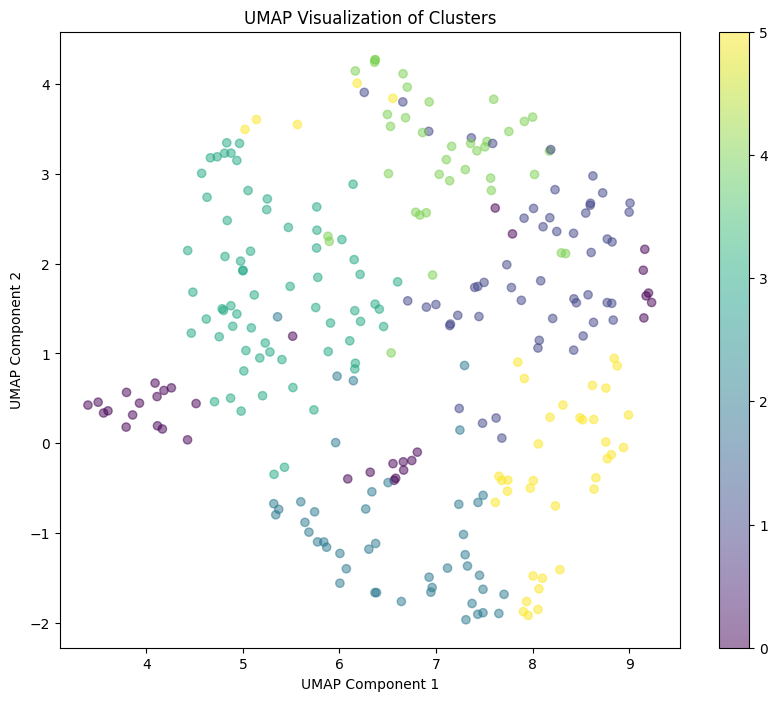

In [74]:
ts_clusterer.viz()

In [75]:
res_final['label'] = res_final['label'].astype(int)
alignment_df = res_final.groupby('sample')[['cluster', 'label']].agg('mean').astype(int)

In [76]:
random_label = np.random.randint(alignment_df['label'].max(), size=alignment_df.shape[0])
alignment_df = alignment_df.assign(random_label=random_label)

In [77]:
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

res_final.cluster = res_final.cluster.astype(int)

print(f"ARI: {adjusted_rand_score(alignment_df['cluster'], alignment_df['label'])}")
print(f"AMI: {adjusted_mutual_info_score(alignment_df['cluster'], alignment_df['label'])}")


print(f"ARI control: {adjusted_rand_score(alignment_df['cluster'], alignment_df['random_label'])}")
print(f"AMI control: {adjusted_mutual_info_score(alignment_df['cluster'], alignment_df['random_label'])}")


ARI: 0.09179824233911667
AMI: 0.1487013745941704
ARI control: -0.0040451451261802945
AMI control: -0.007590843358245644
